# Validador de Estrategias v0.2 — Mes 4, Semana 2

## 1. Instalación y descarga de datos reales

In [10]:
# --- BLOQUE 1: INSTALA VECTORBT Y DESCARGA DATOS REALES ---

# Instalar vectorbt — solo una vez por sesión
!pip install vectorbt -q

import vectorbt as vbt
import yfinance as yf
import pandas as pd
import numpy as np

# --- DESCARGAR DATOS DE LAS 3 AEROLÍNEAS ---
tickers = ['DAL', 'UAL', 'AAL']
nombres = {'DAL': 'Delta', 'UAL': 'United', 'AAL': 'American'}

# 2 años de precios diarios de cierre
precios = yf.download(tickers, period='2y', auto_adjust=True)['Close']
precios.columns = [nombres[t] for t in precios.columns]
precios = precios.dropna()

print('Datos descargados:')
print(f'Período: {precios.index[0].date()} → {precios.index[-1].date()}')
print(f'Días de trading: {len(precios)}')
print('\nÚltimos 5 días:')
print(precios.tail())

# --- RENTABILIDADES ACUMULADAS ---
rentabilidad = ((precios.iloc[-1] - precios.iloc[0]) /
                precios.iloc[0] * 100).round(1)
print('\nRentabilidad acumulada 2 años:')
for empresa, rent in rentabilidad.items():
    print(f'  {empresa}: {rent}%')

[*********************100%***********************]  3 of 3 completed

Datos descargados:
Período: 2024-05-01 → 2026-05-01
Días de trading: 502

Últimos 5 días:
            American      Delta     United
Date                                      
2026-04-27    11.680  68.199997  91.900002
2026-04-28    11.640  67.220001  90.410004
2026-04-29    11.310  66.269997  88.620003
2026-04-30    11.710  67.989998  90.000000
2026-05-01    11.825  69.089996  92.610001

Rentabilidad acumulada 2 años:
  American: -12.9%
  Delta: 41.3%
  United: 82.8%


## 2. Señales de trading — media móvil

=== SEÑALES GENERADAS ===
Señales de compra por empresa:
American    5
Delta       7
United      3
dtype: int64

Señales de venta por empresa:
American    4
Delta       6
United      3
dtype: int64


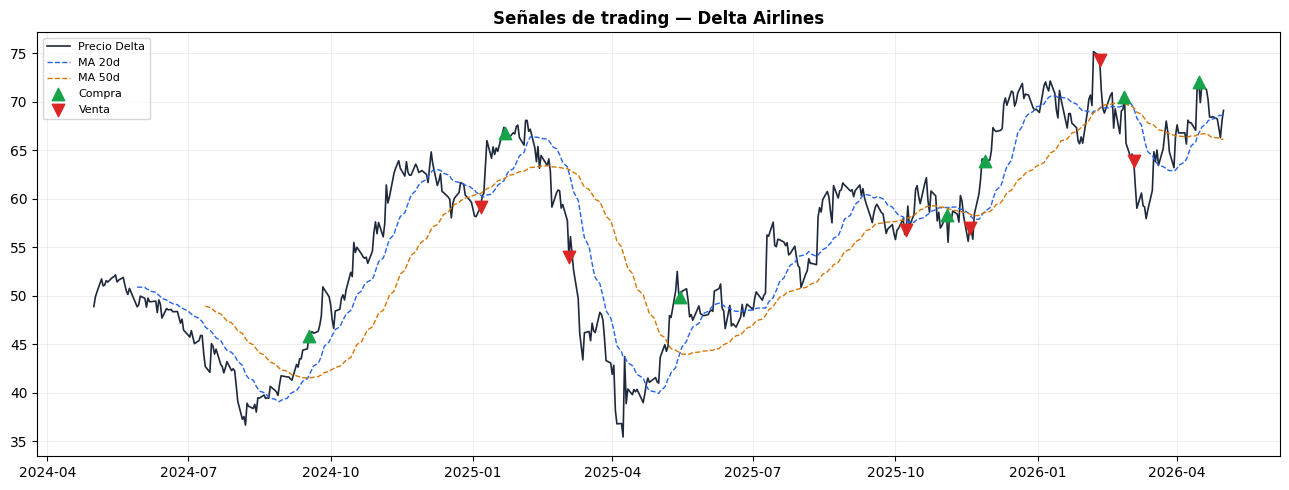

In [11]:
# --- BLOQUE 2: SEÑALES DE TRADING — MEDIA MÓVIL ---

# --- MEDIAS MÓVILES ---
# Media rápida: 20 días  │  Media lenta: 50 días
ventana_rapida = 20
ventana_lenta  = 50

ma_rapida = precios.rolling(ventana_rapida).mean()
ma_lenta  = precios.rolling(ventana_lenta).mean()

# --- SEÑALES DE COMPRA Y VENTA ---
# La media rápida estaba por debajo y ahora está por encima → compra
entradas = (ma_rapida > ma_lenta) & (ma_rapida.shift(1) <= ma_lenta.shift(1))

# La media rápida estaba por encima y ahora está por debajo → venta
salidas  = (ma_rapida < ma_lenta) & (ma_rapida.shift(1) >= ma_lenta.shift(1))

print('=== SEÑALES GENERADAS ===')
print('Señales de compra por empresa:')
print(entradas.sum())
print('\nSeñales de venta por empresa:')
print(salidas.sum())

# --- VISUALIZAR SEÑALES EN DELTA ---
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(precios.index, precios['Delta'],
        label='Precio Delta', linewidth=1.2, color='#1e293b')
ax.plot(precios.index, ma_rapida['Delta'],
        label=f'MA {ventana_rapida}d', linewidth=1,
        color='#2563eb', linestyle='--')
ax.plot(precios.index, ma_lenta['Delta'],
        label=f'MA {ventana_lenta}d', linewidth=1,
        color='#d97706', linestyle='--')

# Marcar señales de compra y venta
compras_delta = precios['Delta'][entradas['Delta']]
ventas_delta  = precios['Delta'][salidas['Delta']]
ax.scatter(compras_delta.index, compras_delta.values,
           marker='^', color='#16a34a', s=80, zorder=5, label='Compra')
ax.scatter(ventas_delta.index, ventas_delta.values,
           marker='v', color='#dc2626', s=80, zorder=5, label='Venta')

ax.set_title('Señales de trading — Delta Airlines',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('senales_trading.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Backtest con vectorbt

In [12]:
# --- BLOQUE 3: BACKTEST CON VECTORBT ---

# Capital inicial: 10.000€ por empresa (30.000€ total)
capital_inicial = 10000

# Crear el portfolio
portfolio = vbt.Portfolio.from_signals(
    close=precios,
    entries=entradas,
    exits=salidas,
    init_cash=capital_inicial,
    fees=0.001,        # comisión del 0.1% por operación
    slippage=0.001,    # deslizamiento del 0.1%
    freq='D'           # frecuencia diaria
)

# --- MÉTRICAS POR EMPRESA ---
print('\n=== RENDIMIENTO POR EMPRESA ===')
for empresa in precios.columns:
    stats = portfolio.stats(column=empresa)
    print(f'\n{empresa}:')
    print(f'  Total Return:  {stats["Total Return [%]"]:.1f}%')
    print(f'  Sharpe Ratio:  {stats["Sharpe Ratio"]:.2f}')
    print(f'  Max Drawdown:  {stats["Max Drawdown [%]"]:.1f}%')
    print(f'  Win Rate:      {stats["Win Rate [%]"]:.1f}%')


=== RENDIMIENTO POR EMPRESA ===

American:
  Total Return:  47.8%
  Sharpe Ratio:  0.94
  Max Drawdown:  27.9%
  Win Rate:      50.0%

Delta:
  Total Return:  14.2%
  Sharpe Ratio:  0.45
  Max Drawdown:  31.5%
  Win Rate:      50.0%

United:
  Total Return:  151.4%
  Sharpe Ratio:  1.93
  Max Drawdown:  23.3%
  Win Rate:      100.0%


## 4. Equity curve y comparativa con buy & hold

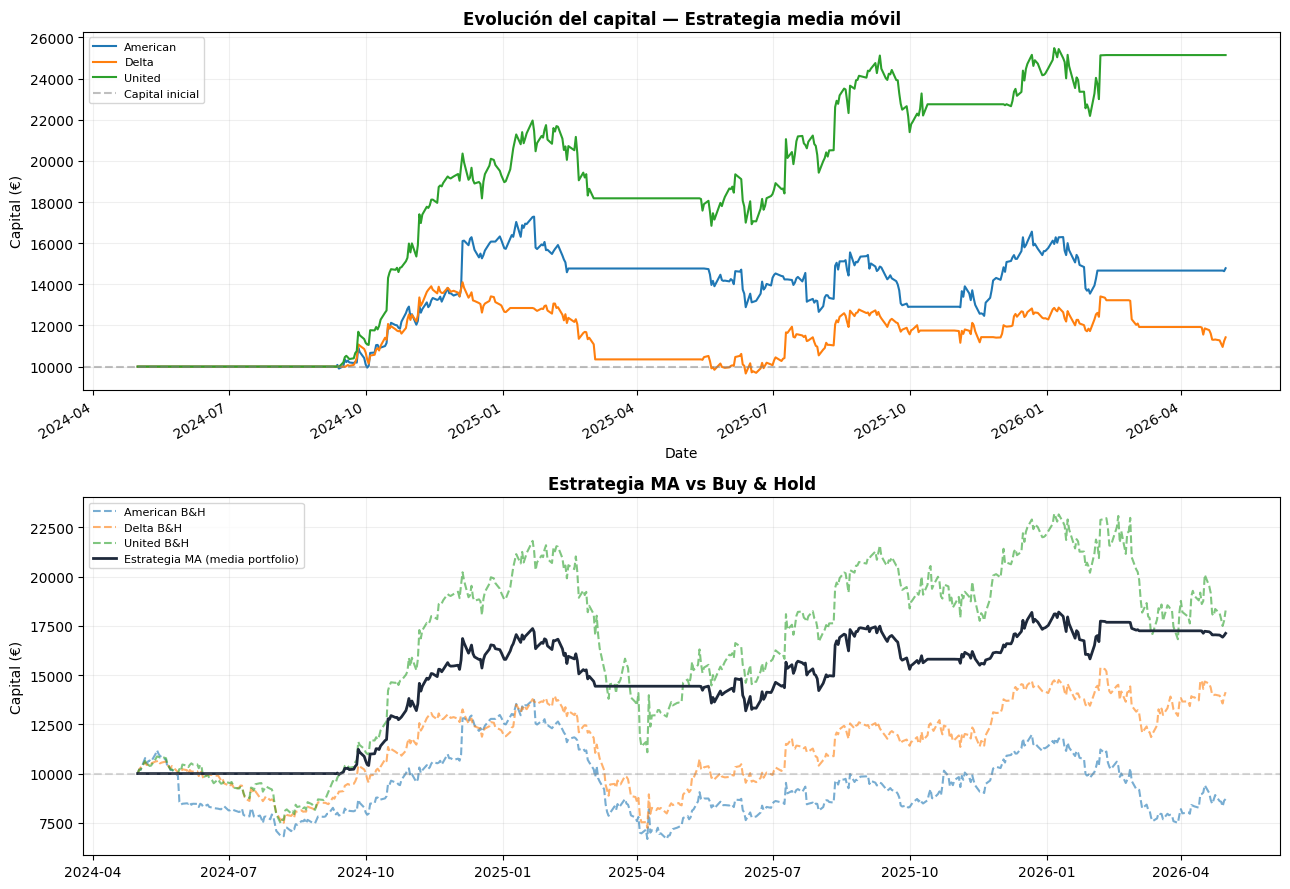

Equity curve guardada como equity_curve.png


In [13]:
# --- BLOQUE 4: EQUITY CURVE Y COMPARATIVA CON BUY & HOLD ---

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(13, 9))

# --- PANEL 1: Valor del portfolio en el tiempo ---
portfolio.value().plot(ax=axes[0])
axes[0].set_title('Evolución del capital — Estrategia media móvil',
                   fontsize=12, fontweight='bold')
axes[0].set_ylabel('Capital (€)')
axes[0].axhline(y=capital_inicial, color='gray',
                linestyle='--', alpha=0.5, label='Capital inicial')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.2)

# --- PANEL 2: Comparativa con buy & hold ---
# Buy & hold: comprar al inicio y mantener hasta el final
buy_hold = (precios / precios.iloc[0]) * capital_inicial
estrategia_val = portfolio.value()

for col in buy_hold.columns:
    axes[1].plot(buy_hold.index, buy_hold[col],
                 linestyle='--', alpha=0.6, label=f'{col} B&H')
axes[1].plot(estrategia_val.index,
             estrategia_val.mean(axis=1),
             color='#1e293b', linewidth=2,
             label='Estrategia MA (media portfolio)')

axes[1].set_title('Estrategia MA vs Buy & Hold',
                   fontsize=12, fontweight='bold')
axes[1].set_ylabel('Capital (€)')
axes[1].axhline(y=capital_inicial, color='gray',
                linestyle='--', alpha=0.3)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('equity_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Equity curve guardada como equity_curve.png')